In [14]:
import sys
sys.path.insert(0, "/Users/c_yang/Library/CloudStorage/OneDrive-Personal/nus/project/1_RuO2_stability/src")

import numpy as np
from matplotlib import pyplot as plt
from build_model import load_bulk_db, build_surface_model, build_interface_model, make_simple_supercell

plt.style.use("acs")

## Load bulks from database

In [15]:
bulks = load_bulk_db("../working/dataset/RuO2_bulk_opt.db")
print(list(bulks.keys()))

['Ru-Hcp-r2scan', 'RuO2-SiF4-rpbe', 'RuO2-Fluorite-pbe', 'RuO2-SiF4-pbe', 'Ru-Fcc-r2scan', 'Ru-Fcc-pbe', 'RuO2-Fluorite-r2scan', 'Ru-Hcp-pbe', 'RuO2-Rutile-rpbe', 'RuO2-SiF4-r2scan', 'RuO2-Rutile-r2scan', 'Ru-Hcp-rpbe', 'RuO2-Rutile-pbe', 'RuO2-Cubic-rpbe', 'RuO2-Fluorite-rpbe', 'RuO2-Cubic-r2scan', 'RuO2-Cubic-pbe', 'Ru-Fcc-rpbe']


## Build surface model based on given parameters

In [19]:
bulk_info = "RuO2-Rutile-pbe"
miller_index = [0, 1, 1]
layers = 6 # Layer of Ru-O units
vacuum = 20 # Angstrom
terminations = None #["Ru", "O"] # For "Ru" or "O" termination, it returns None
min_lattice = 12 # Minimum lattice vector length in Angstrom

In [17]:
surface = build_surface_model(bulks[bulk_info], miller_index, layers, vacuum, terminations)
if len(surface) == 0:
    print("No valid surface found.")
else:
    print(f"Number of surfaces found: {len(surface)}")

Number of surfaces found: 3


In [22]:
super_surf = []
for surf in surface:
    print(f"Surface info: {surf.cell.cellpar()}, {surf.get_chemical_formula()}")
    super_surf.append(make_simple_supercell(surf, min_lattice))

Surface info: [ 3.1242727   6.39392899 39.18153542 90.02066997 89.99998998 89.99999631], O22Ru10
Surface info: [ 3.1242727   6.39392899 39.18153542 90.02066997 89.99998998 89.99999631], O24Ru12
Surface info: [ 3.1242727   6.39392899 39.18153542 90.02066997 89.99998998 89.99999631], O22Ru12


In [23]:
view(super_surf)

<Popen: returncode: None args: ['/Users/c_yang/opt/conda/envs/matsim/bin/pyt...>

## Build interface model based on given parameters

In [25]:
from ase.build import molecule
molecule("H3O")

KeyError: 'H3O'

In [6]:
from ase.visualize import view
view(surface)

<Popen: returncode: None args: ['/Users/c_yang/opt/conda/envs/matsim/bin/pyt...>

## Supercell transformation

### Illustration of slab

In [131]:
from ase.build import fcc111, fcc100, fcc110, hcp0001

results = {
    "fcc111": fcc111("Pt", a=1, size=(2, 2, 4), vacuum=15).cell.array,
    "fcc100": fcc100("Pt", a=1, size=(2, 2, 4), vacuum=15).cell.array,
    "fcc110": fcc110("Pt", a=1, size=(2, 2, 4), vacuum=15).cell.array,
    "hcp0001": hcp0001("Ti", a=1, size=(2, 2, 4), vacuum=15).cell.array,
}

In [ ]:
import itertools

def supercell_transformation(lattice, TM):
    for p in itertools.product(range(1, 5), repeat=2):
        if p == (1, 1):
            continue
        

def cell2plot(cell, projection=0):
    if cell.shape != (3, 3):
        raise ValueError("Cell must be a 3x3 matrix.")
    
    unmask = [i for i in range(3) if i != projection]
    vector = cell[np.ix_(unmask, unmask)]
    origin = np.zeros(2)

    return np.array([
        [origin, vector[0]],
        [vector[0], vector[0]+vector[1]],
        [vector[0]+ vector[1], vector[1]],
        [vector[1], origin]
    ])


supercell_transformation(c, 1)

(1, 2)
(1, 3)
(1, 4)
(2, 1)
(2, 2)
(2, 3)
(2, 4)
(3, 1)
(3, 2)
(3, 3)
(3, 4)
(4, 1)
(4, 2)
(4, 3)
(4, 4)


(4, 2, 2)
(4, 2, 2)
(4, 2, 2)
(4, 2, 2)


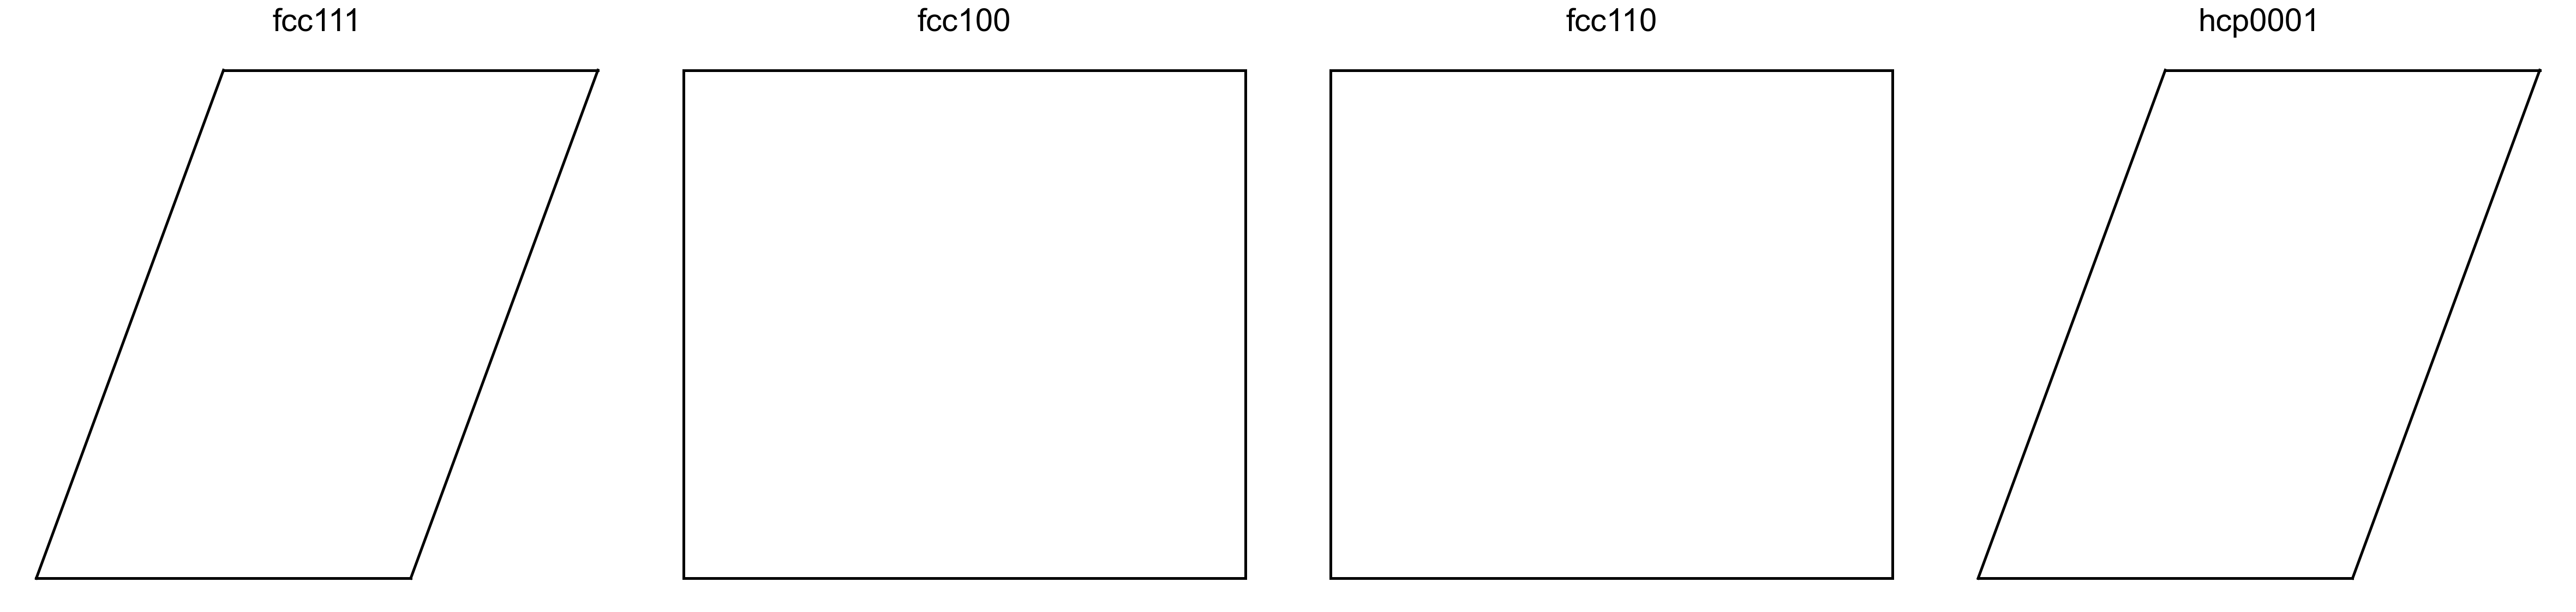

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 4), tight_layout=True)
for i, (l, c) in enumerate(results.items()):
    data = cell2plot(c, projection=2)
    print(data.shape)
    for n in range(data.shape[0]):
        ax[i].plot(*data[n].T, color="k", ls="-")
    ax[i].axis("off")
    ax[i].set_title(l)
    


In [144]:
projection = 1
cell_mask = np.ones((3, 3), dtype=bool)
cell_mask[projection, :] = False
cell_mask[:, projection] = False

In [147]:
c = np.arange(20, 29).reshape((3, 3))
c[cell_mask]

array([20, 22, 26, 28])